In [20]:
# Monte Carlo simulation of 2024 tournament using saved model
import joblib
import pandas as pd
import numpy as np
from pathlib import Path

import re
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import math

In [15]:
# Define paths for model and tournament data
MODEL_PATH = Path("models/xgb_march_madness_model.joblib")

# Path to matchup features CSV
MATCHUPS_PATH = Path("data/processed/MNCAATourneyMatchupFeatures.csv")

# Load matchup features
df_matchups = pd.read_csv(MATCHUPS_PATH)

# Load trained model
model = joblib.load(MODEL_PATH)

In [16]:
# Simulate tournament matchups from processed feature differences

# Select numeric feature columns (robust to minor column variations)
numeric_cols = df_matchups.select_dtypes(include=["number"]).columns.tolist()

# If a known expected feature set exists, intersect to ensure order
expected_feat_cols = [
    "eFG_diff", "TOVp_diff", "ORBp_diff", "FTR_diff",
    "ORtg_diff", "DRtg_diff", "win_rate_diff", "seed_num_diff",
]
feat_cols = [c for c in expected_feat_cols if c in numeric_cols]
if not feat_cols:
    # Fall back to using all numeric columns
    feat_cols = numeric_cols

# Prefer the exact feature names used by the trained model when available
feat_names = getattr(model, "feature_names_in_", None)
if feat_names is not None:
    # Keep only those the model expects; preserve order
    feat_cols = [c for c in feat_names if c in (set(numeric_cols) | set(expected_feat_cols))]
    # If still empty for any reason, keep the earlier detection
    if not feat_cols:
        feat_cols = list(feat_names)

In [17]:
# Build and simulate the NCAA bracket using Seeds and Slots
import re
from collections import defaultdict, deque

# Paths to Kaggle data and team features
DATA_ROOT = Path("data/relevant_data")
SEEDS_PATH = DATA_ROOT / "MNCAATourneySeeds.csv"
SLOTS_PATH = DATA_ROOT / "MNCAATourneySlots.csv"
TEAMS_PATH = DATA_ROOT / "MTeams.csv"
TEAM_FEATURES_PATH = Path("data/processed/team_data.csv")

# Load datasets
seeds_df = pd.read_csv(SEEDS_PATH)
slots_df = pd.read_csv(SLOTS_PATH)
teams_df = pd.read_csv(TEAMS_PATH)

# Optional: team-level features per season for feature diffs
team_feat_df = None
if TEAM_FEATURES_PATH.exists():
    team_feat_df = pd.read_csv(TEAM_FEATURES_PATH)

# Choose the season to simulate: prefer 2024 if available else the latest in common
available_seasons = sorted(set(seeds_df["Season"]).intersection(set(slots_df["Season"])))
latest_season = 2025  # 2024 if 2024 in available_seasons else max(available_seasons)

# Filter season data
seeds = seeds_df[seeds_df["Season"] == latest_season].copy()
slots = slots_df[slots_df["Season"] == latest_season].copy()

# Helpers
seed_num_re = re.compile(r"^[WXYZ](\d{2})[ab]?$", re.I)

def seed_number(seed_str: str) -> int:
    m = seed_num_re.match(seed_str)
    return int(m.group(1)) if m else 99

# Map seed -> team for the season (includes play-in a/b seeds)
seed_to_teamid = dict(zip(seeds["Seed"], seeds["TeamID"]))

# Map TeamID -> TeamName for pretty printing
team_name = dict(zip(teams_df["TeamID"], teams_df["TeamName"]))

# Optionally, build per-season team features for quick access
team_features = {}
if team_feat_df is not None and "Season" in team_feat_df.columns and "TeamID" in team_feat_df.columns:
    # keep only this season if present
    tf = team_feat_df.copy()
    if latest_season in set(tf.get("Season", pd.Series([], dtype=int))):
        tf = tf[tf["Season"] == latest_season]
    for _, r in tf.iterrows():
        team_features[int(r["TeamID"])] = r.to_dict()

# Determine which base stat columns we can use to construct diffs
base_feat_cols = ["eFG", "TOVp", "ORBp", "FTR", "ORtg", "DRtg", "win_rate"]
avail_cols = []
if team_features:
    # Inspect any one row to detect available columns
    sample = next(iter(team_features.values()))
    avail_cols = [c for c in base_feat_cols if c in sample]

# Construct a single-row feature vector for a matchup (A vs B)
# Returns: (X_df[feat_cols], feature_column_names actually provided)
def build_feature_row(team_a: int, team_b: int, seed_a: str, seed_b: str):
    row_vals = {}

    # From team features if available
    if avail_cols:
        fa = team_features.get(team_a, {})
        fb = team_features.get(team_b, {})
        for c in avail_cols:
            row_vals[f"{c}_diff"] = float(fa.get(c, np.nan)) - float(fb.get(c, np.nan))

    # Seed number diff (align with training: positive favors Team A)
    # Training used seed_num_diff = seed2 - seed1 (Team1 advantage -> positive)
    row_vals["seed_num_diff"] = seed_number(seed_b) - seed_number(seed_a)

    # From precomputed matchup features CSV if present and provides more fields
    # Try to find a direct row for this exact A,B pair (any reasonable column naming)
    # This is optional enrichment; we'll only add fields that aren't already present
    candidate = None
    if 'Season' in df_matchups.columns:
        # Try common id column names
        id_pairs = [
            ("TeamAID", "TeamBID"), ("Team1ID", "Team2ID"), ("A_TeamID", "B_TeamID"),
        ]
        for ca, cb in id_pairs:
            if ca in df_matchups.columns and cb in df_matchups.columns:
                sub = df_matchups[(df_matchups["Season"] == latest_season) &
                                  (df_matchups[ca] == team_a) & (df_matchups[cb] == team_b)]
                if not sub.empty:
                    candidate = sub.iloc[0].to_dict()
                    break
    if candidate is not None:
        for k, v in candidate.items():
            if k.endswith("_diff") and k not in row_vals and isinstance(v, (int, float, np.floating)):
                row_vals[k] = float(v)

    # Build DataFrame with only the columns our model will consume
    # Use feat_cols computed earlier, but only those present in row_vals
    use_cols = [c for c in feat_cols if c in row_vals]
    # If nothing matched, fall back to any numeric diffs we computed
    if not use_cols:
        use_cols = [k for k in row_vals.keys() if k.endswith("_diff") or k == "seed_num_diff"]

    X_row = pd.DataFrame([[row_vals.get(c, 0.0) for c in use_cols]], columns=use_cols)
    return X_row, use_cols

# ---- Probability calibration helpers ----
# Calibrated column index for "Team A wins"
_WIN_COL = int(np.where(getattr(model, "classes_", np.array([0, 1])) == 1)[0][0]) if hasattr(model, "classes_") else 1

def _to_model_X(X_row: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Reorder / align a single-row DataFrame to the model's expected feature order."""
    feat_names = getattr(model, "feature_names_in_", None)
    if feat_names is None:
        # Fall back: assume current column order is acceptable
        return X_row
    # Build full row in expected order, filling missing with 0.0
    vals = []
    for c in feat_names:
        if c in X_row.columns:
            vals.append(float(X_row[c].iloc[0]))
        else:
            vals.append(0.0)
    return pd.DataFrame([vals], columns=list(feat_names))

def predict_matchup_prob(team_a: int, team_b: int, seed_a: str, seed_b: str) -> float:
    """Return P(Team A wins) from the trained model."""
    # Build features for orientation A vs B
    Xa_row, cols_a = build_feature_row(team_a, team_b, seed_a, seed_b)
    Xa = _to_model_X(Xa_row, cols_a)

    # Probability Team A (Team1) wins is the positive class index
    pA = float(model.predict_proba(Xa)[0][_WIN_COL])
    return pA

def simulate_bracket_once(stochastic: bool = False, rng: np.random.Generator | None = None):
    """Simulate one full tournament bracket.

    If stochastic is False, picks the higher probability team in each game.
    If stochastic is True, samples game results according to win probabilities.

    Returns:
        winners: dict mapping slot -> (team_id, seed_str)
        match_meta: list of per-game dicts with probabilities and upset info.
    """
    if stochastic and rng is None:
        rng = np.random.default_rng()

    winners = {}  # slot -> (team_id, original_seed_str)

    def resolve(entry: str):
        # If it's a seed name in the seeds table
        if entry in seed_to_teamid:
            tid = int(seed_to_teamid[entry])
            return tid, entry
        # Else, it must refer to a prior slot
        if entry in winners:
            return winners[entry]
        return None

    remaining = set(slots["Slot"].tolist())
    match_meta = []  # keep some logs per game

    while remaining:
        progressed = False
        for _, row in slots.iterrows():
            slot = row["Slot"]
            if slot not in remaining:
                continue
            a_ref = row["StrongSeed"]
            b_ref = row["WeakSeed"]
            ra = resolve(a_ref)
            rb = resolve(b_ref)
            if ra is None or rb is None:
                continue  # can't play yet
            team_a, seed_a = ra
            team_b, seed_b = rb

            # Predict P(Team A wins)
            p_A = predict_matchup_prob(team_a, team_b, seed_a, seed_b)
            p_B = 1.0 - p_A

            # Determine which is underdog by seed number (higher number = worse seed)
            seed_num_a = seed_number(seed_a)
            seed_num_b = seed_number(seed_b)
            if seed_num_a == seed_num_b:
                underdog = None
                p_underdog = min(p_A, p_B)
            elif seed_num_a > seed_num_b:
                underdog = "A"
                p_underdog = p_A
            else:
                underdog = "B"
                p_underdog = p_B

            # Decide winner
            if stochastic:
                # Sample outcome based on p_A
                winA = bool(rng.random() < p_A)
            else:
                # Deterministic: higher probability
                winA = p_A >= p_B

            if winA:
                win_id, win_seed, win_p, lose_id, lose_p = team_a, seed_a, p_A, team_b, p_B
            else:
                win_id, win_seed, win_p, lose_id, lose_p = team_b, seed_b, p_B, team_a, p_A

            winners[slot] = (win_id, win_seed)
            remaining.remove(slot)
            progressed = True

            a_label = f"{team_name.get(team_a, team_a)} ({seed_a})"
            b_label = f"{team_name.get(team_b, team_b)} ({seed_b})"

            # Mark whether the realized result was an upset (winner was underdog by seed)
            realized_upset = False
            if underdog == "A" and winA:
                realized_upset = True
            elif underdog == "B" and not winA:
                realized_upset = True

            match_meta.append({
                "slot": slot,
                "A": a_label,
                "B": b_label,
                "seedA": seed_a,
                "seedB": seed_b,
                "seed_num_A": seed_num_a,
                "seed_num_B": seed_num_b,
                "pA": float(round(p_A, 4)),
                "pB": float(round(p_B, 4)),
                "winner": team_name.get(win_id, win_id),
                "winner_seed": win_seed,
                "winner_p": float(round(win_p, 4)),
                "winA": winA,
                "underdog_side": underdog,
                "p_underdog": float(round(p_underdog, 4)),
                "realized_upset": realized_upset,
            })
        if not progressed:
            # Safety to avoid infinite loop if data inconsistent
            break

    return winners, match_meta

# --- Single deterministic simulation (for bracket drawing) ---
winners, match_meta = simulate_bracket_once(stochastic=False)

# Determine champion: final slot is the one that's referenced by no other slot
referenced = set(slots["StrongSeed"]).union(set(slots["WeakSeed"]))
final_slots = [s for s in slots["Slot"].tolist() if s not in referenced]
champ_slot = final_slots[0] if final_slots else slots.iloc[-1]["Slot"]
champ_id, champ_seed = winners.get(champ_slot, (None, None))
champ_name = team_name.get(champ_id, str(champ_id)) if champ_id is not None else "Unknown"

print(f"Season {latest_season} champion (deterministic): {champ_name} ({champ_seed})")

# Show a concise per-round summary
# Build reverse graph: for each slot, which next slot consumes it
consumers = defaultdict(list)
for _, r in slots.iterrows():
    consumers[r["StrongSeed"].item() if hasattr(r["StrongSeed"], 'item') else r["StrongSeed"]].append(r["Slot"])
    consumers[r["WeakSeed"].item() if hasattr(r["WeakSeed"], 'item') else r["WeakSeed"]].append(r["Slot"])

# Determine round number by BFS from seeds to final
round_of = {}
q = deque()
# Initial entries are the seeds that appear in any slot
seed_entries = set(slots["StrongSeed"]).union(set(slots["WeakSeed"]))
for e in seed_entries:
    if e in seed_to_teamid:  # actual seeds
        round_of[e] = 0
        q.append(e)
while q:
    e = q.popleft()
    rnum = round_of[e]
    for nxt in consumers.get(e, []):
        if nxt not in round_of:
            round_of[nxt] = rnum + 1
            q.append(nxt)

# Group matches by round number of their slot
round_matches = defaultdict(list)
for m in match_meta:
    rnd = round_of.get(m["slot"], -1)
    round_matches[rnd].append(m)

for rnd in sorted(round_matches.keys()):
    print(f"\nRound {rnd} results:")
    for m in round_matches[rnd]:
        upset_flag = " (UPSET)" if m["realized_upset"] else ""
        print(f"  {m['slot']}: {m['A']} vs {m['B']} -> Winner: {m['winner']} (p={m['winner_p']}, p_underdog={m['p_underdog']}){upset_flag}")

Season 2025 champion (deterministic): Duke (W01)

Round 1 results:
  R1W2: Alabama (W02) vs Robert Morris (W15) -> Winner: Alabama (p=0.906, p_underdog=0.094)
  R1W3: Wisconsin (W03) vs Montana (W14) -> Winner: Wisconsin (p=0.8906, p_underdog=0.1094)
  R1W4: Arizona (W04) vs Akron (W13) -> Winner: Arizona (p=0.8276, p_underdog=0.1724)
  R1W5: Oregon (W05) vs Liberty (W12) -> Winner: Oregon (p=0.7791, p_underdog=0.2209)
  R1W6: BYU (W06) vs VCU (W11) -> Winner: BYU (p=0.6801, p_underdog=0.3199)
  R1W7: St Mary's CA (W07) vs Vanderbilt (W10) -> Winner: St Mary's CA (p=0.7751, p_underdog=0.2249)
  R1W8: Mississippi St (W08) vs Baylor (W09) -> Winner: Mississippi St (p=0.715, p_underdog=0.285)
  R1X1: Houston (X01) vs SIUE (X16) -> Winner: Houston (p=0.9215, p_underdog=0.0785)
  R1X2: Tennessee (X02) vs Wofford (X15) -> Winner: Tennessee (p=0.906, p_underdog=0.094)
  R1X3: Kentucky (X03) vs Troy (X14) -> Winner: Kentucky (p=0.8906, p_underdog=0.1094)
  R1X4: Purdue (X04) vs High Point (X13

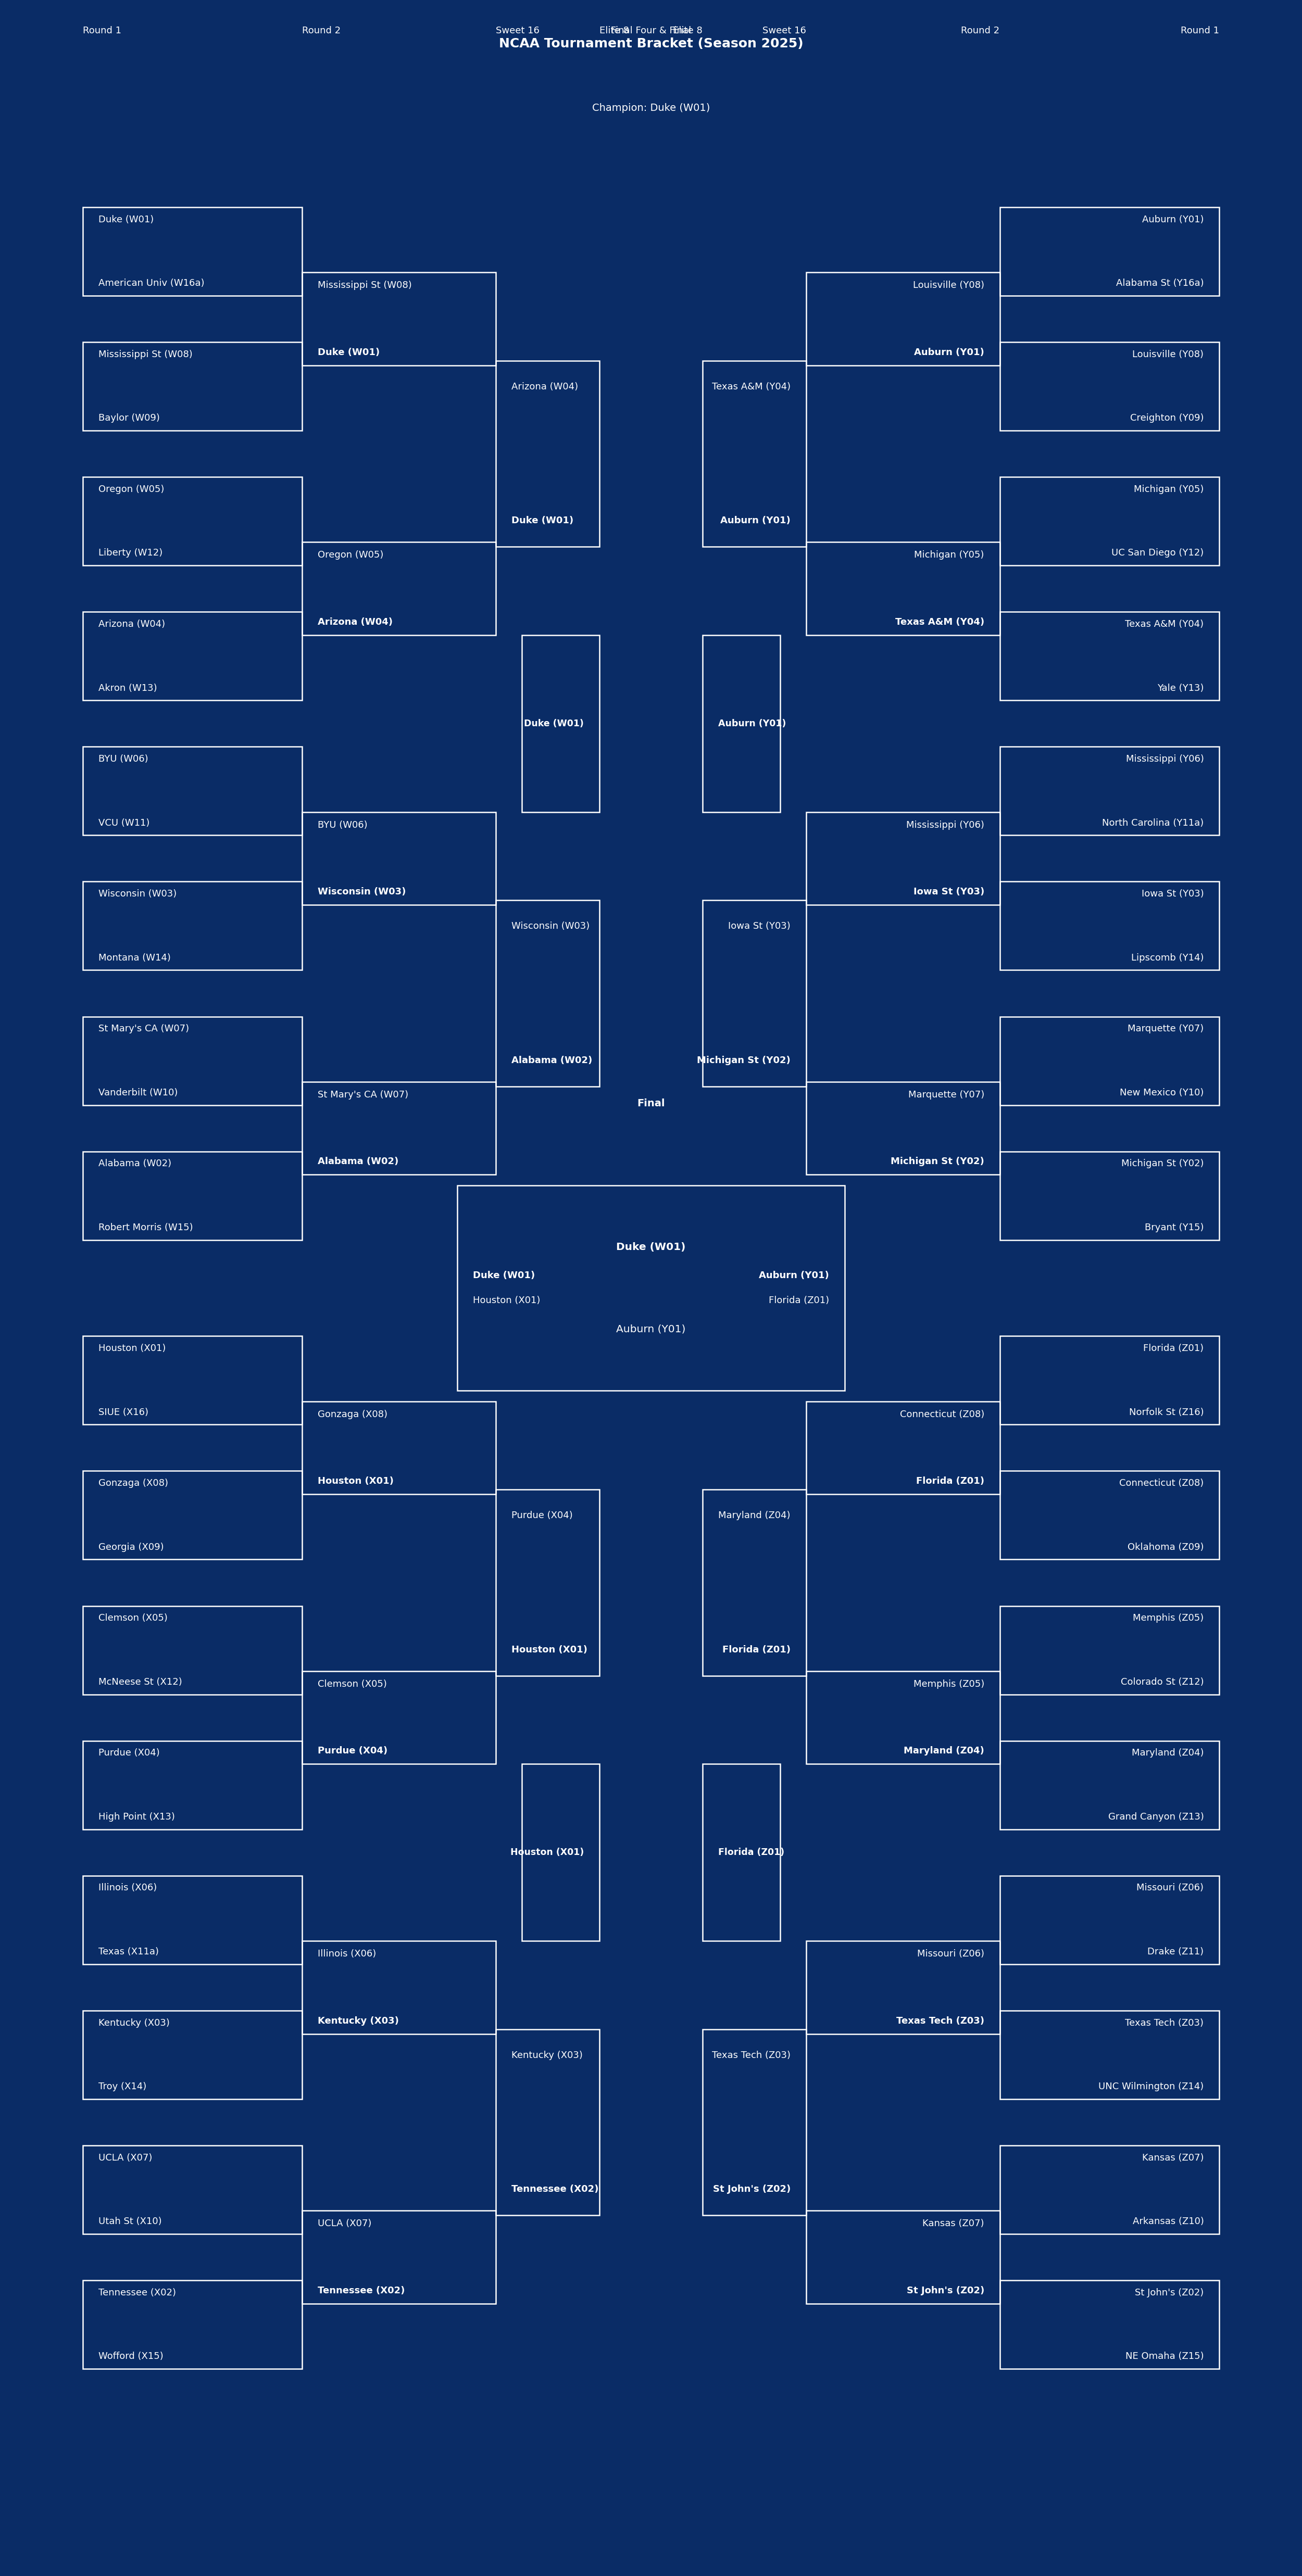

In [18]:
def render_bracket(
    match_meta,
    round_of,
    latest_season,
    champ_name,
    champ_seed,
    left_regions=('W', 'X'),
    right_regions=('Y', 'Z'),
    fig_w=16,
    fig_h=8,
    bg_color='#0A2C66',
    text_color='white'
):
    """
    Render a tournament bracket figure.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """

    # --- Helpers to parse labels ---
    seed_pat_local = re.compile(r"\(([^)]+)\)$")

    def parse_seed(label: str) -> str:
        m = seed_pat_local.search(label)
        return m.group(1) if m else ""

    def seed_region(seed: str) -> str:
        return seed[:1].upper() if seed else ""

    def seed_num(seed: str) -> int:
        s = seed.rstrip('abAB')
        if s and s[0].isalpha():
            s = s[1:]
        try:
            return int(s)
        except Exception:
            return 99

    # Canonical first-round pair order within a region
    canonical_pairs = [(1,16),(8,9),(5,12),(4,13),(6,11),(3,14),(7,10),(2,15)]
    order_index = {tuple(sorted(p)): i for i, p in enumerate(canonical_pairs)}
    seed_to_pair_idx = {s:i for i,(a,b) in enumerate(canonical_pairs) for s in (a,b)}

    left_regions = list(left_regions)
    right_regions = list(right_regions)
    all_regions = left_regions + right_regions

    # Build round 1 pairs per region (skip play-ins)
    r1_matches = [m for m in match_meta if round_of.get(m['slot'], -1) == 1]
    region_pairs = {r: [] for r in all_regions}
    for m in r1_matches:
        sA = parse_seed(m['A']); sB = parse_seed(m['B'])
        rA = seed_region(sA); rB = seed_region(sB)
        if rA and rA == rB and rA in region_pairs:
            idx = order_index.get(tuple(sorted((seed_num(sA), seed_num(sB)))), None)
            if idx is None:
                continue
            region_pairs[rA].append({'idx': idx, 'A': m['A'], 'B': m['B']})
    for r in region_pairs:
        region_pairs[r].sort(key=lambda x: x['idx'])
        region_pairs[r] = region_pairs[r][:8]

    # Collect matches per round per region
    region_rounds = {r: {1: [], 2: [], 3: [], 4: []} for r in all_regions}
    for m in match_meta:
        sA = parse_seed(m['A']); sB = parse_seed(m['B'])
        rA = seed_region(sA); rB = seed_region(sB)
        rnd = round_of.get(m['slot'], -1)
        if rA == rB and rA in region_rounds and rnd in (1,2,3,4):
            region_rounds[rA][rnd].append(m)

    # Sort later rounds for reproducibility
    for r in all_regions:
        for rnd in (2,3,4):
            region_rounds[r][rnd].sort(
                key=lambda m: min(seed_num(parse_seed(m['A'])),
                                  seed_num(parse_seed(m['B'])))
            )

    regional_champs = {r: None for r in all_regions}
    for r in all_regions:
        if region_rounds[r][4]:
            mm = region_rounds[r][4][0]
            regional_champs[r] = (mm['winner'], mm['winner_seed'])

    # Final Four and Final
    final_four = []
    final_match = None
    for m in match_meta:
        sA = parse_seed(m['A']); sB = parse_seed(m['B'])
        rA = seed_region(sA); rB = seed_region(sB)
        rnd = round_of.get(m['slot'], -1)
        if rnd >= 5 and (not rA or not rB or rA != rB):
            if rnd == 5:
                final_four.append(m)
            else:
                final_match = m

    # --- Layout parameters / figure ---
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_facecolor(bg_color)
    fig.patch.set_facecolor(bg_color)

    # Column x-positions (ensure gap around center)
    cols_left = [0.06, 0.23, 0.38, 0.46]
    cols_center = 0.50
    cols_right = [0.94, 0.77, 0.62, 0.54]

    # Region bands (top -> bottom)
    band_left = {'W': (0.92, 0.52), 'X': (0.48, 0.08)}
    band_right = {'Y': (0.92, 0.52), 'Z': (0.48, 0.08)}

    # --- drawing helpers ---

    def draw_box(x_left, x_right, y_center, height, edge='white', face='none', lw=1.8):
        xl, xr = (x_left, x_right) if x_left <= x_right else (x_right, x_left)
        w = (xr - xl)
        rect = patches.Rectangle(
            (xl, y_center - height/2.0), w, height,
            linewidth=lw, edgecolor=edge, facecolor=face
        )
        ax.add_patch(rect)
        return xl, xr

    def draw_boxed_match(
        x_left, x_right, y_center, box_h,
        team1, team2,
        align='left', winner_idx=None, fontsize=13
    ):
        inset = 0.012
        xl, xr = draw_box(x_left, x_right, y_center, box_h)
        y_gap = box_h * 0.36
        if align == 'right':
            x_text = xr - inset
            ha = 'right'
        elif align == 'center':
            x_text = (xl + xr) / 2.0
            ha = 'center'
        else:
            x_text = xl + inset
            ha = 'left'
        fw1 = 'bold' if winner_idx == 0 else 'normal'
        fw2 = 'bold' if winner_idx == 1 else 'normal'
        ax.text(x_text, y_center + y_gap, team1,
                color=text_color, ha=ha, va='center',
                fontsize=fontsize, fontweight=fw1)
        ax.text(x_text, y_center - y_gap, team2,
                color=text_color, ha=ha, va='center',
                fontsize=fontsize, fontweight=fw2)

    def draw_region(region: str, side: str):
        if side == 'left':
            x_cols = cols_left
            y_top, y_bot = band_left[region]
            align = 'left'
        else:
            x_cols = cols_right
            y_top, y_bot = band_right[region]
            align = 'right'

        pairs = region_pairs.get(region, [])
        n_pairs = len(pairs)
        if n_pairs == 0:
            return {'ys_r1': [], 'ys_r2': [], 'ys_r3': [], 'y_ch': None}

        H = abs(y_top - y_bot)
        step = H / n_pairs
        band_pad = step * 0.18
        inner_gap1 = step * 0.46
        box_h_r1 = inner_gap1 * 1.5
        pair_centers = np.linspace(
            y_top - step/2 + band_pad,
            y_bot + step/2 - band_pad,
            n_pairs
        )

        ys_r1 = []
        for i in range(n_pairs):
            rec = pairs[i]
            y_mid = pair_centers[i]
            ys_r1.append(y_mid)
            draw_boxed_match(
                x_cols[0], x_cols[1], y_mid, box_h_r1,
                rec['A'], rec['B'], align=align,
                winner_idx=None, fontsize=13
            )

        ys_r2 = [
            (ys_r1[2*k] + ys_r1[2*k+1]) / 2.0
            for k in range(max(1, n_pairs//2))
        ]
        inner_gap2 = (ys_r1[1] - ys_r1[0]) * 0.46 if n_pairs > 1 else inner_gap1
        box_h_r2 = inner_gap2 * 1.5

        matches_r2 = region_rounds[region][2]
        for m in matches_r2:
            sA = seed_num(parse_seed(m['A']))
            sB = seed_num(parse_seed(m['B']))
            pA = seed_to_pair_idx.get(sA, 0)
            pB = seed_to_pair_idx.get(sB, 0)
            grp = min(pA, pB) // 2
            if grp < len(ys_r2):
                y = ys_r2[grp]
                winner_idx = 0 if m.get('winA', False) else 1
                draw_boxed_match(
                    x_cols[1], x_cols[2], y, box_h_r2,
                    m['A'], m['B'],
                    align=align, winner_idx=winner_idx, fontsize=13
                )

        ys_r3 = [
            (ys_r2[2*k] + ys_r2[2*k+1]) / 2.0
            for k in range(max(1, len(ys_r2)//2))
        ]
        inner_gap3 = (ys_r2[1] - ys_r2[0]) * 0.46 if len(ys_r2) > 1 else inner_gap2
        box_h_r3 = inner_gap3 * 1.5

        matches_r3 = region_rounds[region][3]
        for m in matches_r3:
            sA = seed_num(parse_seed(m['A']))
            sB = seed_num(parse_seed(m['B']))
            pA = seed_to_pair_idx.get(sA, 0)
            pB = seed_to_pair_idx.get(sB, 0)
            grp2 = (min(pA, pB) // 2) // 2
            if grp2 < len(ys_r3):
                y = ys_r3[grp2]
                winner_idx = 0 if m.get('winA', False) else 1
                draw_boxed_match(
                    x_cols[2], x_cols[3], y, box_h_r3,
                    m['A'], m['B'],
                    align=align, winner_idx=winner_idx, fontsize=13
                )

        champ = regional_champs.get(region)
        y_ch = None
        if champ:
            if len(ys_r3) >= 2:
                y_ch = (ys_r3[0] + ys_r3[1]) / 2.0
            elif ys_r3:
                y_ch = ys_r3[0]
            else:
                y_ch = np.mean([y_top, y_bot])

            if side == 'left':
                draw_box(x_cols[3]-0.06, x_cols[3], y_ch, box_h_r3*0.95)
                ax.text(
                    x_cols[3]-0.012, y_ch,
                    f"{champ[0]} ({champ[1]})",
                    color=text_color, ha='right', va='center',
                    fontsize=12.5, fontweight='bold'
                )
            else:
                draw_box(x_cols[3], x_cols[3]+0.06, y_ch, box_h_r3*0.95)
                ax.text(
                    x_cols[3]+0.012, y_ch,
                    f"{champ[0]} ({champ[1]})",
                    color=text_color, ha='left', va='center',
                    fontsize=12.5, fontweight='bold'
                )

        return {'ys_r1': ys_r1, 'ys_r2': ys_r2, 'ys_r3': ys_r3, 'y_ch': y_ch}

    # Draw regions and collect champion y-positions
    pos_left = {r: draw_region(r, side='left') for r in left_regions}
    pos_right = {r: draw_region(r, side='right') for r in right_regions}

    # Compute semifinal centers
    y_sem_left = None
    y_sem_right = None
    if (pos_left.get('W', {}).get('y_ch') is not None and
        pos_left.get('X', {}).get('y_ch') is not None):
        y_sem_left = (pos_left['W']['y_ch'] + pos_left['X']['y_ch']) / 2.0
    if (pos_right.get('Y', {}).get('y_ch') is not None and
        pos_right.get('Z', {}).get('y_ch') is not None):
        y_sem_right = (pos_right['Y']['y_ch'] + pos_right['Z']['y_ch']) / 2.0

    center_pad = 0.08
    if y_sem_left is not None:
        y_sem_left -= center_pad
    if y_sem_right is not None:
        y_sem_right += center_pad

    # Final box
    if final_match and y_sem_left is not None and y_sem_right is not None:
        y_final = (y_sem_left + y_sem_right) / 2.0
        final_width = 0.30
        final_height = 0.08
        xl, xr = draw_box(
            cols_center-final_width/2,
            cols_center+final_width/2,
            y_final, final_height
        )

        ax.text(
            cols_center,
            y_final + (final_height/2) + 0.030,
            "Final",
            color=text_color, ha='center', va='bottom',
            fontsize=14, fontweight='bold'
        )

        inset = 0.012
        semi_line_gap = final_height * 0.06

        # Left semi
        if len(final_four) >= 1:
            m_left = final_four[0]
            y1 = y_final + semi_line_gap
            y2 = y_final - semi_line_gap
            fw1 = 'bold' if m_left.get('winA', False) else 'normal'
            fw2 = 'bold' if not m_left.get('winA', False) else 'normal'
            ax.text(
                xl + inset, y1, m_left['A'],
                color=text_color, ha='left', va='center',
                fontsize=13, fontweight=fw1
            )
            ax.text(
                xl + inset, y2, m_left['B'],
                color=text_color, ha='left', va='center',
                fontsize=13, fontweight=fw2
            )

        # Right semi
        if len(final_four) >= 2:
            m_right = final_four[1]
            y1 = y_final + semi_line_gap
            y2 = y_final - semi_line_gap
            fw1 = 'bold' if m_right.get('winA', False) else 'normal'
            fw2 = 'bold' if not m_right.get('winA', False) else 'normal'
            ax.text(
                xr - inset, y1, m_right['A'],
                color=text_color, ha='right', va='center',
                fontsize=13, fontweight=fw1
            )
            ax.text(
                xr - inset, y2, m_right['B'],
                color=text_color, ha='right', va='center',
                fontsize=13, fontweight=fw2
            )

        # Finalists
        y_gap = final_height * 0.20
        fwA = 'bold' if final_match.get('winA', False) else 'normal'
        fwB = 'bold' if not final_match.get('winA', False) else 'normal'
        ax.text(
            cols_center, y_final + y_gap, final_match['A'],
            color=text_color, ha='center', va='center',
            fontsize=14.5, fontweight=fwA
        )
        ax.text(
            cols_center, y_final - y_gap, final_match['B'],
            color=text_color, ha='center', va='center',
            fontsize=14.5, fontweight=fwB
        )

    # Title and champion
    ax.text(
        0.5, 0.985,
        f"NCAA Tournament Bracket (Season {latest_season})",
        color=text_color, ha='center', va='center',
        fontsize=18, fontweight='bold'
    )
    ax.text(
        0.5, 0.96,
        f"Champion: {champ_name} ({champ_seed})",
        color=text_color, ha='center', va='center',
        fontsize=14
    )

    # Round headings
    ax.text(cols_left[0], 0.99, 'Round 1', color=text_color,
            ha='left', va='center', fontsize=13)
    ax.text(cols_left[1], 0.99, 'Round 2', color=text_color,
            ha='left', va='center', fontsize=13)
    ax.text(cols_left[2], 0.99, 'Sweet 16', color=text_color,
            ha='left', va='center', fontsize=13)
    ax.text(cols_left[3], 0.99, 'Elite 8', color=text_color,
            ha='left', va='center', fontsize=13)
    ax.text(cols_center, 0.99, 'Final Four & Final', color=text_color,
            ha='center', va='center', fontsize=13)
    ax.text(cols_right[3], 0.99, 'Elite 8', color=text_color,
            ha='right', va='center', fontsize=13)
    ax.text(cols_right[2], 0.99, 'Sweet 16', color=text_color,
            ha='right', va='center', fontsize=13)
    ax.text(cols_right[1], 0.99, 'Round 2', color=text_color,
            ha='right', va='center', fontsize=13)
    ax.text(cols_right[0], 0.99, 'Round 1', color=text_color,
            ha='right', va='center', fontsize=13)

    # Resize before render; caller can override if desired
    w, h = fig.get_size_inches()
    fig.set_size_inches(w * 2, h * 8, forward=True)

    return fig, ax

# Render the bracket figure
fig, ax = render_bracket(
    match_meta, round_of, latest_season, champ_name, champ_seed,
    left_regions=('W', 'X'), right_regions=('Y', 'Z'),
    fig_w=16, fig_h=8,
    bg_color='#0A2C66', text_color='white'
)

### Adding upset predictions

In [ ]:
# Monte Carlo simulation to estimate upset frequencies across brackets

def run_monte_carlo_brackets(n_sim: int = 1000, upset_seed_gap: int = 2, rng_seed: int = 42):
    """Run many stochastic bracket simulations and estimate upset frequencies.

    Args:
        n_sim: number of bracket simulations.
        upset_seed_gap: minimum seed-number gap to count as an upset candidate
                        (e.g. 2 means 5 vs 7 is not an upset, 5 vs 8 is).
        rng_seed: seed for reproducible randomness.

    Returns:
        upset_summary: DataFrame with per-slot upset stats.
    """
    rng = np.random.default_rng(rng_seed)

    # Aggregate stats keyed by (slot, A_label, B_label) to keep matchups aligned
    stats = {}  # key -> dict

    for sim_idx in range(n_sim):
        winners_sim, match_meta_sim = simulate_bracket_once(stochastic=True, rng=rng)
        for m in match_meta_sim:
            slot = m["slot"]
            A = m["A"]
            B = m["B"]
            key = (slot, A, B)

            # Derive seed numbers
            seed_num_A = m["seed_num_A"]
            seed_num_B = m["seed_num_B"]

            # Determine if this is an upset *candidate* based on seed gap
            seed_gap = abs(seed_num_A - seed_num_B)
            is_upset_candidate = seed_gap >= upset_seed_gap and seed_num_A != seed_num_B

            if key not in stats:
                stats[key] = {
                    "slot": slot,
                    "A": A,
                    "B": B,
                    "seedA": m["seedA"],
                    "seedB": m["seedB"],
                    "seed_num_A": seed_num_A,
                    "seed_num_B": seed_num_B,
                    "games_played": 0,
                    "upset_wins": 0,
                    "is_upset_candidate": is_upset_candidate,
                }
            rec = stats[key]

            # Keep candidate flag ORed across simulations (should be stable anyway)
            rec["is_upset_candidate"] = rec["is_upset_candidate"] or is_upset_candidate

            rec["games_played"] += 1

            if not is_upset_candidate:
                continue

            # Realized upset if winner was the worse seed
            if m["realized_upset"]:
                rec["upset_wins"] += 1

    # Convert to DataFrame
    if not stats:
        return pd.DataFrame()

    upset_df = pd.DataFrame(list(stats.values()))
    upset_df["upset_prob_given_played"] = upset_df.apply(
    lambda r: (r["upset_wins"] / r["games_played"]) if r["games_played"] > 0 else 0.0, axis=1)
    upset_df["play_prob"] = upset_df["games_played"] / float(n_sim)
    upset_df["joint_upset_prob"] = upset_df["upset_prob_given_played"] * upset_df["play_prob"]

    # Filter to genuine upset candidates only
    upset_df = upset_df[upset_df["is_upset_candidate"]].copy()

    return upset_df.sort_values("joint_upset_prob", ascending=False)

# Run a modest Monte Carlo to get a feel for upsets (can increase n_sim for more accuracy)
upset_results = run_monte_carlo_brackets(n_sim=500, upset_seed_gap=3, rng_seed=RNG_SEED) if "RNG_SEED" in globals() else run_monte_carlo_brackets(n_sim=500, upset_seed_gap=3)

print("Top 15 likely upsets by joint probability (prob game happens * prob underdog wins):")
cols_to_show = [
    "slot", "A", "B", "seedA", "seedB",
    "games_played", "upset_wins",
    "play_prob", "upset_prob_given_played", "joint_upset_prob",
]
display(upset_results[cols_to_show].head(15))

Top 15 likely upsets by joint probability (prob game happens * prob underdog wins):


,slot,A,B,seedA,seedB,games_played,upset_wins,play_prob,upset_prob_given_played,joint_upset_prob
4,R1W6,BYU (W06),VCU (W11),W06,W11,500,155,1.000,0.310000,0.310
25,R1Z6,Missouri (Z06),Drake (Z11),Z06,Z11,500,147,1.000,0.294000,0.294
3,R1W5,Oregon (W05),Liberty (W12),W05,W12,500,129,1.000,0.258000,0.258
5,R1W7,St Mary's CA (W07),Vanderbilt (W10),W07,W10,500,126,1.000,0.252000,0.252
12,R1X7,UCLA (X07),Utah St (X10),X07,X10,500,126,1.000,0.252000,0.252
37,R2Z2,St John's (Z02),Kansas (Z07),Z02,Z07,359,120,0.718,0.334262,0.240
18,R1Y7,Marquette (Y07),New Mexico (Y10),Y07,Y10,500,120,1.000,0.240000,0.240
24,R1Z5,Memphis (Z05),Colorado St (Z12),Z05,Z12,500,119,1.000,0.238000,0.238
32,R2X2,Tennessee (X02),UCLA (X07),X02,X07,343,112,0.686,0.326531,0.224
11,R1X5,Clemson (X05),McNeese St (X12),X05,X12,500,112,1.000,0.224000,0.224


In [33]:
# Use the upset data to build an "upset‑favoring" bracket and render it

# 1) Get top 10 most likely upsets using existing helper (cell 5)
topN = 10
topN_upsets = run_monte_carlo_brackets(n_sim=500, upset_seed_gap=3).head(topN)

# Represent an upset by (slot, seedA, seedB) so it is seed‑based, not label‑based
topN_seed_keys = set(
    zip(topN_upsets["slot"], topN_upsets["seedA"], topN_upsets["seedB"])
)

def build_upset_favoring_winners_seedwise(base_slots, upset_seed_keys):
    """
    Walk bracket in topological order and build a self‑consistent winners dict.
    For any matchup whose (slot, StrongSeed, WeakSeed) is in upset_seed_keys,
    force the worse seed (higher seed number) to win.
    Otherwise use the original deterministic winner if available.
    """
    winners_map = {}

    # Helper: get numeric seed from seed string like 'W06', 'X11a', etc.
    def seed_num(seed_str: str) -> int:
        return seed_number(seed_str)

    for _, row in base_slots.iterrows():
        slot = row["Slot"]
        sA = row["StrongSeed"]
        sB = row["WeakSeed"]

        # First‑four play‑in or later‑round references might point to previous slots
        def resolve_seed_or_slot(ref):
            if ref in seed_to_teamid:          # a true seed like 'W06' or 'Y16a'
                return int(seed_to_teamid[ref]), ref
            if ref in winners_map:             # a prior slot ID
                return winners_map[ref]
            if ref in winners:                 # fall back to baseline winners if consistent
                return winners[ref]
            return None

        ra = resolve_seed_or_slot(sA)
        rb = resolve_seed_or_slot(sB)
        if ra is None or rb is None:
            # Can't resolve this game yet; skip (mostly for safety)
            continue

        team_a, seed_a = ra
        team_b, seed_b = rb

        # Check if this *seed pairing* is in our upset list for this slot
        key = (slot, seed_a, seed_b)
        if key in upset_seed_keys:
            # Force the underdog win (higher numeric seed)
            if seed_num(seed_a) > seed_num(seed_b):
                winners_map[slot] = (team_a, seed_a)
            else:
                winners_map[slot] = (team_b, seed_b)
        else:
            # Use deterministic winner if defined and consistent with these teams/seeds
            if slot in winners:
                base_id, base_seed = winners[slot]
                # Only accept baseline winner if it matches one of the current teams
                if base_seed == seed_a and base_id == team_a:
                    winners_map[slot] = (team_a, seed_a)
                elif base_seed == seed_b and base_id == team_b:
                    winners_map[slot] = (team_b, seed_b)
                else:
                    # If baseline winner doesn't match (because earlier upsets changed inputs),
                    # re‑pick using probabilities.
                    pA = predict_matchup_prob(team_a, team_b, seed_a, seed_b)
                    winners_map[slot] = (team_a, seed_a) if pA >= 0.5 else (team_b, seed_b)
            else:
                # No baseline; decide by model probability
                pA = predict_matchup_prob(team_a, team_b, seed_a, seed_b)
                winners_map[slot] = (team_a, seed_a) if pA >= 0.5 else (team_b, seed_b)

    return winners_map

# Build a consistent winners map that propagates upsets forward
winners_upset = build_upset_favoring_winners_seedwise(slots, topN_seed_keys)

# 3) Rebuild match_meta from this winners_upset so rendering uses new paths
def rebuild_match_meta_from_winners(winners_map):
    new_match_meta = []

    for _, row in slots.iterrows():
        slot = row["Slot"]
        a_ref = row["StrongSeed"]
        b_ref = row["WeakSeed"]

        def resolve(entry):
            if entry in seed_to_teamid:
                tid = int(seed_to_teamid[entry])
                return tid, entry
            if entry in winners_map:
                return winners_map[entry]
            return None

        ra = resolve(a_ref)
        rb = resolve(b_ref)
        if ra is None or rb is None or slot not in winners_map:
            continue

        team_a, seed_a = ra
        team_b, seed_b = rb

        p_A = predict_matchup_prob(team_a, team_b, seed_a, seed_b)
        p_B = 1.0 - p_A

        seed_num_a = seed_number(seed_a)
        seed_num_b = seed_number(seed_b)

        if seed_num_a == seed_num_b:
            underdog = None
            p_underdog = min(p_A, p_B)
        elif seed_num_a > seed_num_b:
            underdog = "A"
            p_underdog = p_A
        else:
            underdog = "B"
            p_underdog = p_B

        win_id, win_seed = winners_map[slot]
        winA = (win_id == team_a)

        if winA:
            win_p, lose_id, lose_p = p_A, team_b, p_B
        else:
            win_p, lose_id, lose_p = p_B, team_a, p_A

        a_label = f"{team_name.get(team_a, team_a)} ({seed_a})"
        b_label = f"{team_name.get(team_b, team_b)} ({seed_b})"

        realized_upset = (
            (underdog == "A" and winA) or
            (underdog == "B" and not winA)
        )

        new_match_meta.append({
            "slot": slot,
            "A": a_label,
            "B": b_label,
            "seedA": seed_a,
            "seedB": seed_b,
            "seed_num_A": seed_num_a,
            "seed_num_B": seed_num_b,
            "pA": float(round(p_A, 4)),
            "pB": float(round(p_B, 4)),
            "winner": team_name.get(win_id, win_id),
            "winner_seed": win_seed,
            "winner_p": float(round(win_p, 4)),
            "winA": winA,
            "underdog_side": underdog,
            "p_underdog": float(round(p_underdog, 4)),
            "realized_upset": realized_upset,
        })

    return new_match_meta

match_meta_upset = rebuild_match_meta_from_winners(winners_upset)

# Return matchup results by round for the upset‑favoring bracket
round_matches_upset = defaultdict(list)
for m in match_meta_upset:
    rnd = round_of.get(m["slot"], -1)
    round_matches_upset[rnd].append(m)
print("\nUpset‑favoring bracket results by round:")
for rnd in sorted(round_matches_upset.keys()):
    print(f"\nRound {rnd} results:")
    for m in round_matches_upset[rnd]:
        upset_flag = " (UPSET)" if m["realized_upset"] else ""
        print(f"  {m['slot']}: {m['A']} vs {m['B']} -> Winner: {m['winner']} (p={m['winner_p']}, p_underdog={m['p_underdog']}){upset_flag}")


Upset‑favoring bracket results by round:

Round 1 results:
  R1W1: Duke (W01) vs American Univ (W16a) -> Winner: Duke (p=0.9215, p_underdog=0.0785)
  R1W2: Alabama (W02) vs Robert Morris (W15) -> Winner: Alabama (p=0.906, p_underdog=0.094)
  R1W3: Wisconsin (W03) vs Montana (W14) -> Winner: Wisconsin (p=0.8906, p_underdog=0.1094)
  R1W4: Arizona (W04) vs Akron (W13) -> Winner: Arizona (p=0.8276, p_underdog=0.1724)
  R1W5: Oregon (W05) vs Liberty (W12) -> Winner: Liberty (p=0.2209, p_underdog=0.2209) (UPSET)
  R1W6: BYU (W06) vs VCU (W11) -> Winner: VCU (p=0.3199, p_underdog=0.3199) (UPSET)
  R1W7: St Mary's CA (W07) vs Vanderbilt (W10) -> Winner: Vanderbilt (p=0.2249, p_underdog=0.2249) (UPSET)
  R1W8: Mississippi St (W08) vs Baylor (W09) -> Winner: Mississippi St (p=0.715, p_underdog=0.285)
  R1X1: Houston (X01) vs SIUE (X16) -> Winner: Houston (p=0.9215, p_underdog=0.0785)
  R1X2: Tennessee (X02) vs Wofford (X15) -> Winner: Tennessee (p=0.906, p_underdog=0.094)
  R1X3: Kentucky (X03

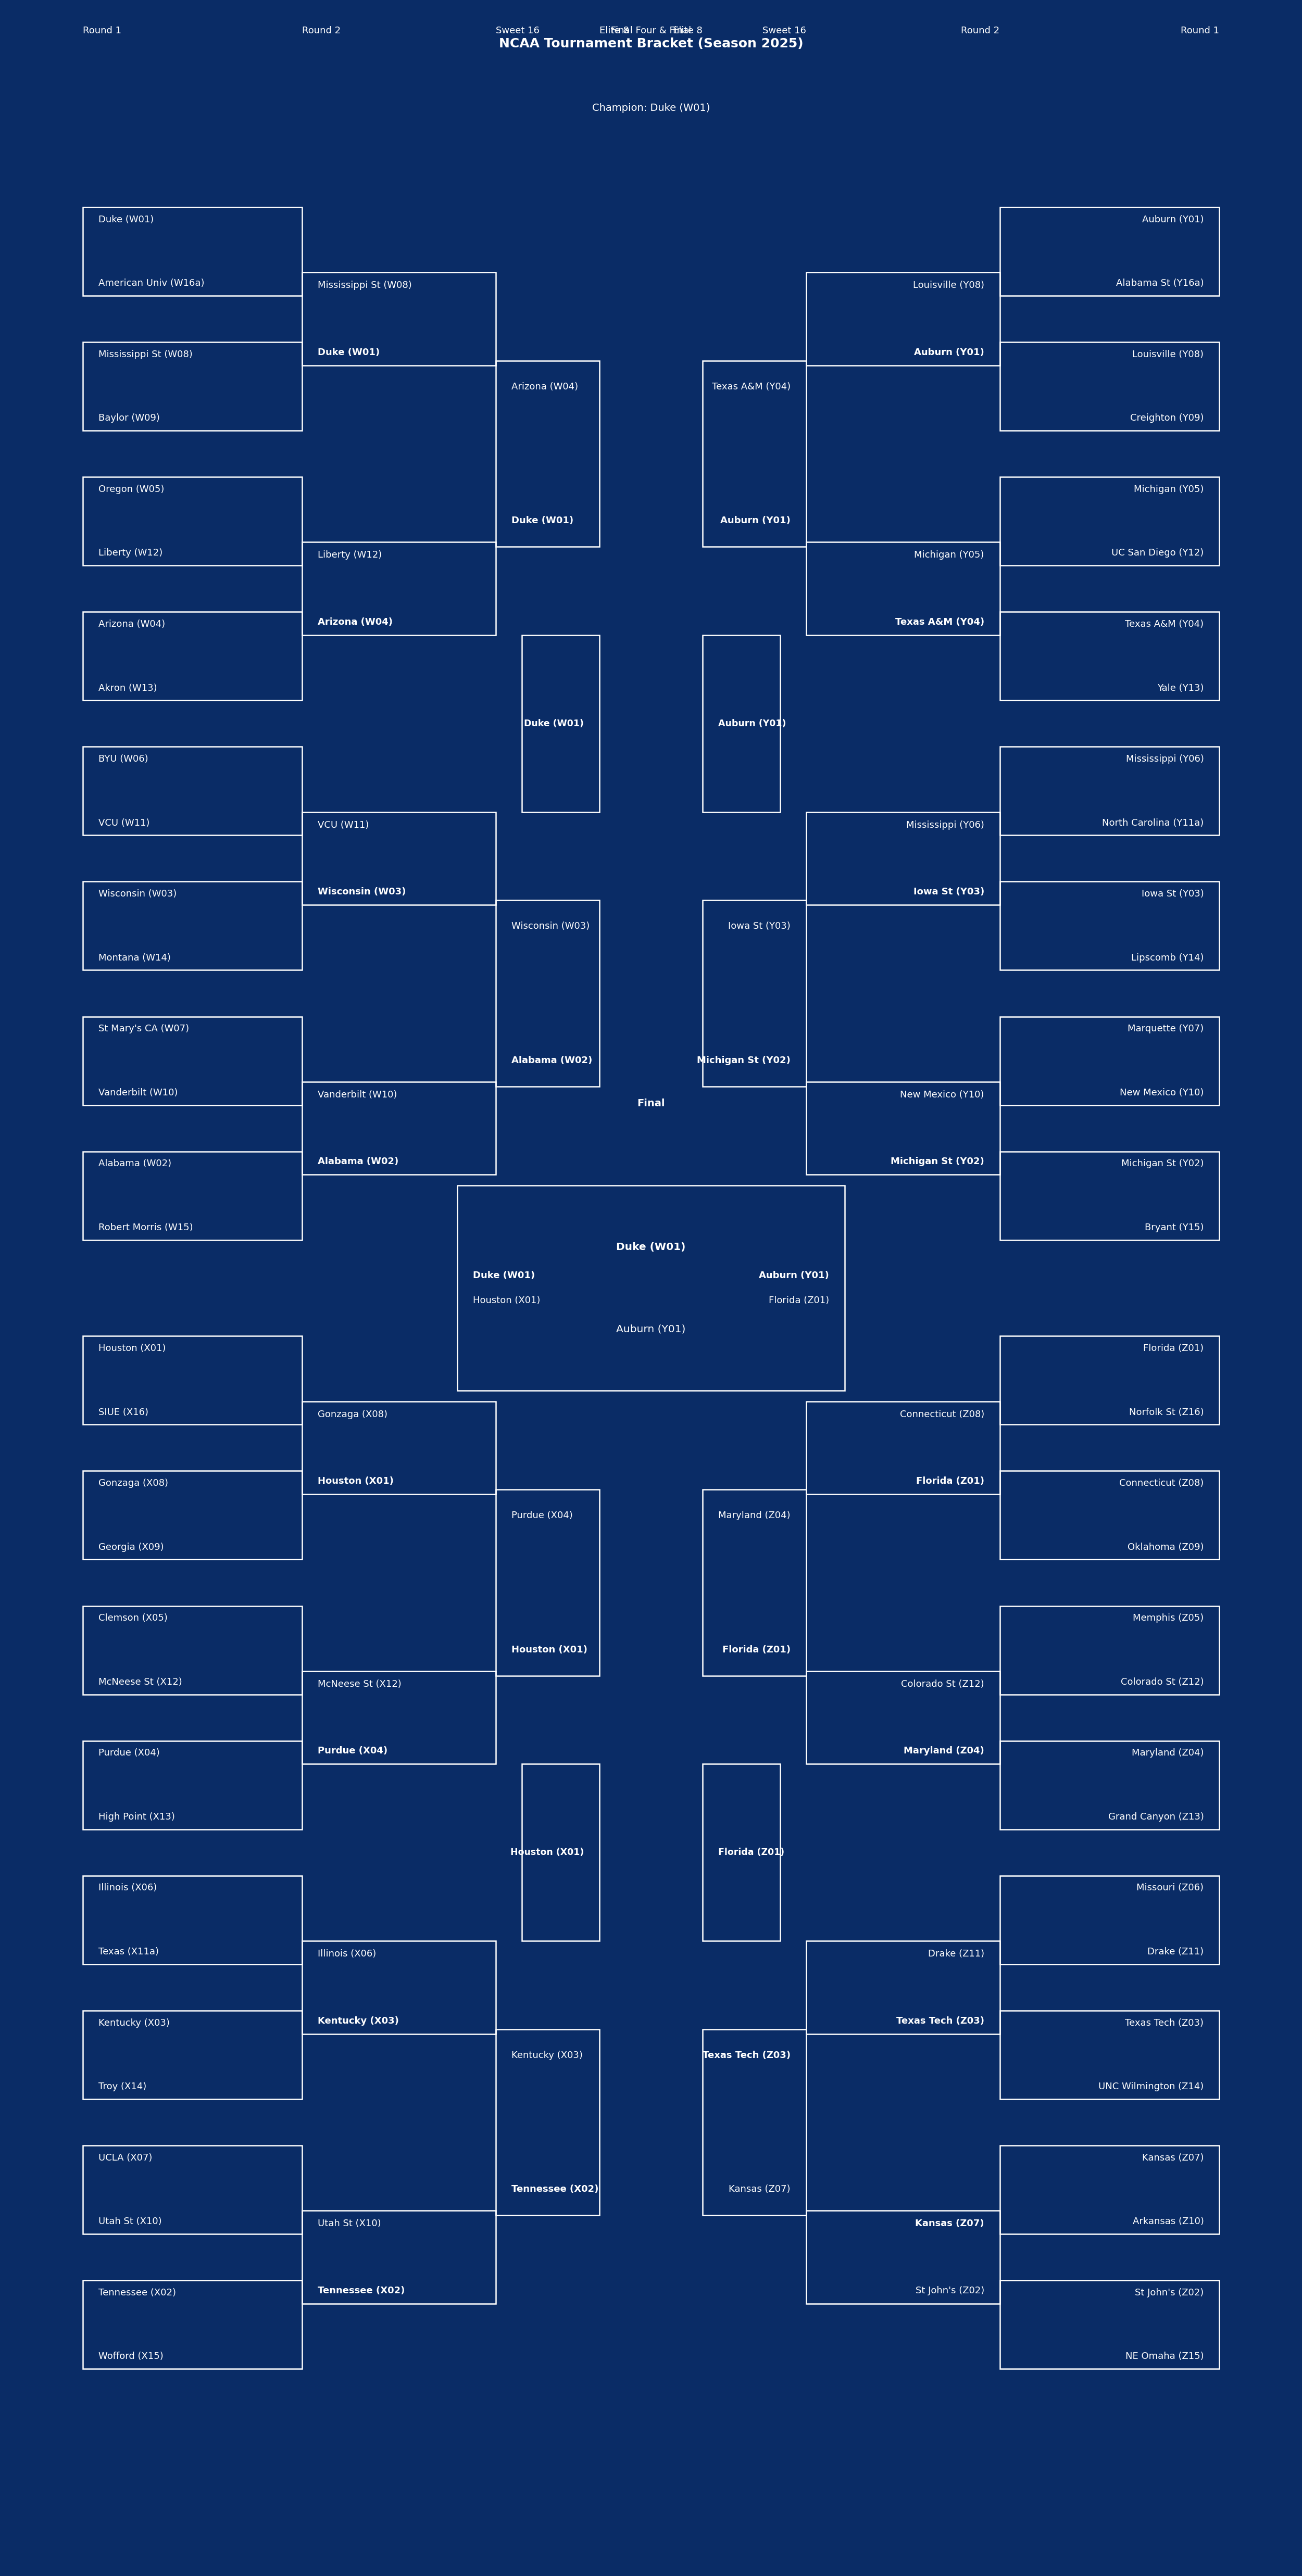

In [30]:

# 4) Determine new champion and render bracket with updated data

referenced = set(slots["StrongSeed"]).union(set(slots["WeakSeed"]))
final_slots = [s for s in slots["Slot"].tolist() if s not in referenced]
champ_slot = final_slots[0] if final_slots else slots.iloc[-1]["Slot"]
champ_id_u, champ_seed_u = winners_upset.get(champ_slot, (None, None))
champ_name_u = team_name.get(champ_id_u, str(champ_id_u)) if champ_id_u is not None else "Unknown"

fig_u, ax_u = render_bracket(
    match_meta_upset, round_of, latest_season,
    champ_name_u, champ_seed_u,
    left_regions=('W', 'X'), right_regions=('Y', 'Z'),
    fig_w=float(w), fig_h=float(h) if "h" in globals() else 8,
    bg_color='#0A2C66', text_color=text_color
)

plt.show()